In [1]:
%cd ..

d:\project\ScratchMLP-SingleChar


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.model import MLP
from src.load_data import load_processed_data, load_emnist_balanced

In [3]:
data = load_processed_data()
if data is not None:
    X_train, Y_train, X_val, Y_val, X_test, Y_test = data
else:
    X_train, Y_train, X_val, Y_val, X_test, Y_test = load_emnist_balanced(validation_split=0.1)

print(f"Data shapes:")
print(f"  Train: {X_train.shape[1]} samples")
print(f"  Validation: {X_val.shape[1]} samples")  
print(f"  Test: {X_test.shape[1]} samples")

Data shapes:
  Train: 101520 samples
  Validation: 11280 samples
  Test: 18800 samples


In [4]:
layer_dims = [784, 512, 256, 47]
mlp = MLP(layer_dims=layer_dims, init='he', lr=0.01)

weights = np.load('models/mlp_weights.npz')
for key in weights.keys():
    mlp.parameters[key] = weights[key]
    
print(f"Loaded parameters: {list(weights.keys())}")

Loaded parameters: ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']


In [5]:
def evaluate_model(mlp, X, Y, dataset_name):
    AL, _ = mlp.forward(X)
    predictions = np.argmax(AL, axis=0)
    true_labels = np.argmax(Y, axis=0)
    accuracy = np.mean(predictions == true_labels)
    loss = mlp.cost(AL, Y)
    
    print(f"{dataset_name} Results:")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Loss: {loss:.4f}")
    print(f"  Samples: {X.shape[1]}")
    print()
    
    return predictions, true_labels, accuracy, loss

train_preds, train_true, train_acc, train_loss = evaluate_model(mlp, X_train, Y_train, "Training")
val_preds, val_true, val_acc, val_loss = evaluate_model(mlp, X_val, Y_val, "Validation") 
test_preds, test_true, test_acc, test_loss = evaluate_model(mlp, X_test, Y_test, "Test")

Training Results:
  Accuracy: 0.8989 (89.89%)
  Loss: 0.2979
  Samples: 101520

Validation Results:
  Accuracy: 0.8388 (83.88%)
  Loss: 0.4932
  Samples: 11280

Test Results:
  Accuracy: 0.8321 (83.21%)
  Loss: 0.5294
  Samples: 18800



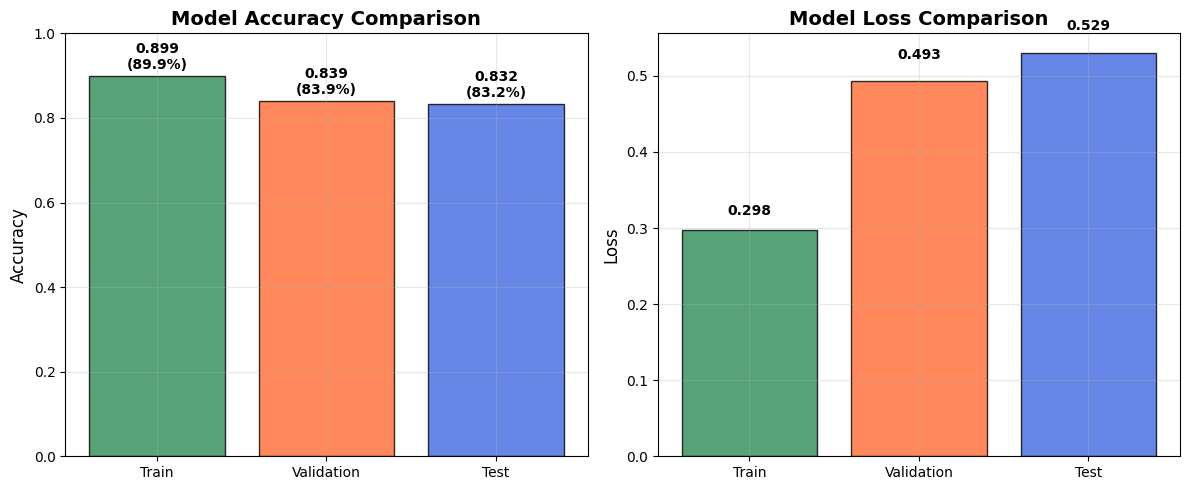

In [6]:
# Plot accuracy and loss comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
datasets = ['Train', 'Validation', 'Test']
accuracies = [train_acc, val_acc, test_acc]
colors = ['#2E8B57', '#FF6B35', '#4169E1']

bars1 = ax1.bar(datasets, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}\n({acc*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

# Loss comparison  
losses = [train_loss, val_loss, test_loss]
bars2 = ax2.bar(datasets, losses, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax2.set_title('Model Loss Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=12)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, loss in zip(bars2, losses):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
             f'{loss:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

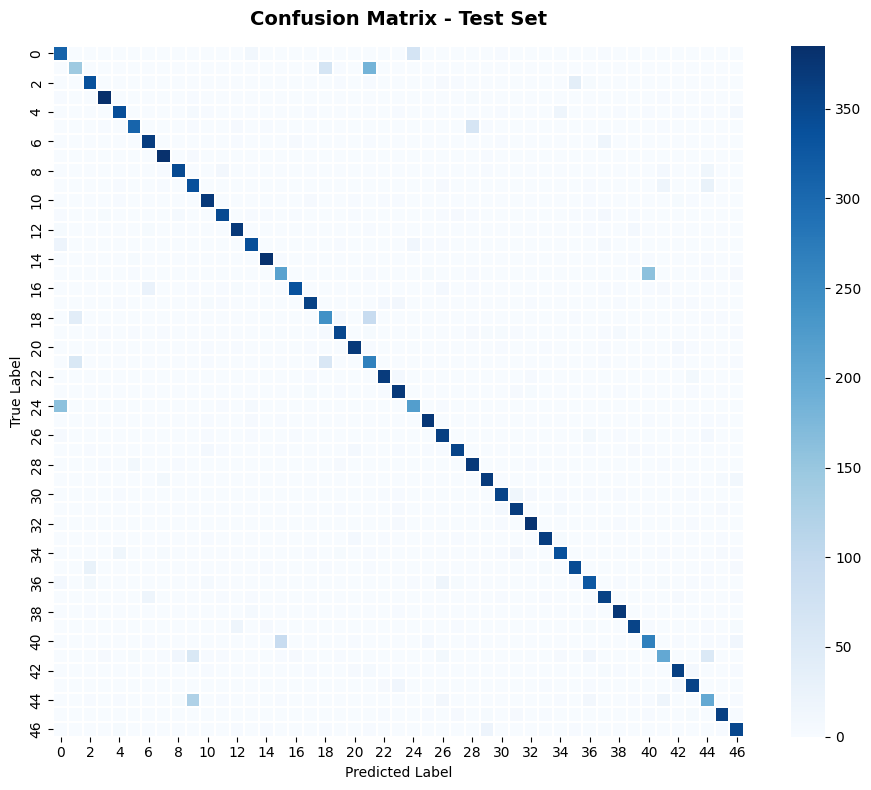

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.5920    0.7725    0.6703       400
           1     0.5878    0.3600    0.4465       400
           2     0.8638    0.8400    0.8517       400
           3     0.9436    0.9625    0.9530       400
           4     0.8997    0.8525    0.8755       400
           5     0.9059    0.7700    0.8324       400
           6     0.8626    0.9100    0.8856       400
           7     0.9249    0.9550    0.9397       400
           8     0.9105    0.8650    0.8872       400
           9     0.6202    0.8450    0.7153       400
          10     0.8854    0.9275    0.9060       400
          11     0.9108    0.8675    0.8886       400
          12     0.9069    0.9250    0.9158       400
          13     0.8782    0.8475    0.8626       400
          14     0.9384    0.9525    0.9454       400
          15     0.6554    0.5325    0.5876       400
          16     0.9410    0.8375    0.8862    

In [7]:
# Confusion Matrix for Test Set
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(test_true, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d', cbar=True, 
            square=True, linewidths=0.1)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report (Test Set):")
print("="*50)
print(classification_report(test_true, test_preds, digits=4))

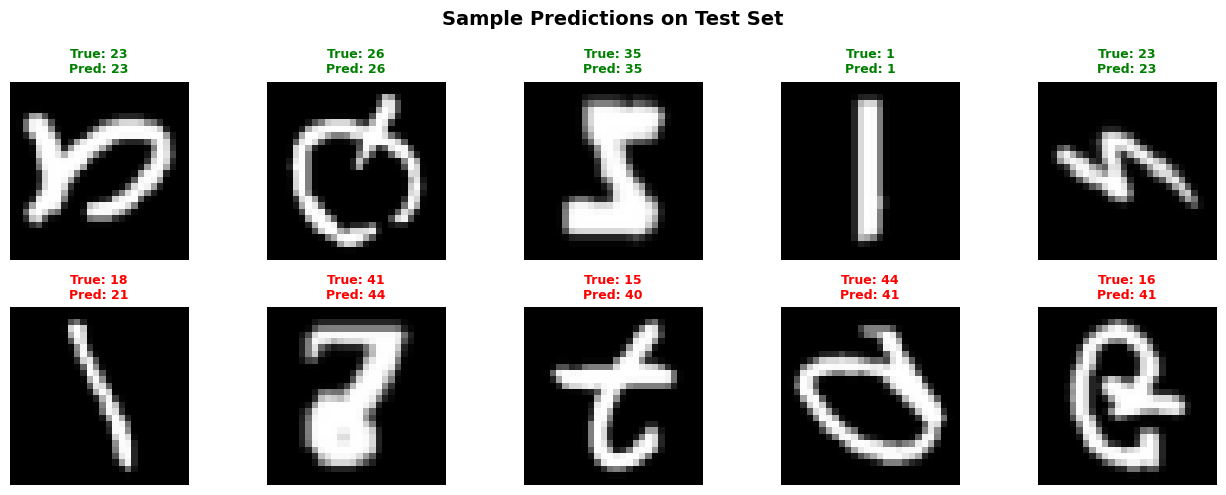

In [8]:
# Sample predictions visualization
def visualize_predictions(X, predictions, true_labels, num_samples=10):
    # Find correct and incorrect predictions
    correct_mask = (predictions == true_labels)
    correct_indices = np.where(correct_mask)[0]
    incorrect_indices = np.where(~correct_mask)[0]
    
    # Sample 5 correct and 5 incorrect predictions
    correct_sample = np.random.choice(correct_indices, 5, replace=False)
    incorrect_sample = np.random.choice(incorrect_indices, 5, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(13, 5))
    fig.suptitle('Sample Predictions on Test Set', fontsize=14, fontweight='bold')
    
    # Plot correct predictions (top row)
    for i, idx in enumerate(correct_sample):
        # Reshape image back to 28x28 (EMNIST images are transposed and flipped)
        img = X[:, idx].reshape(28, 28).T
        img = np.flip(img, axis=0)  # EMNIST specific transformation
        
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].axis('off')
        
        pred_label = predictions[idx]
        true_label = true_labels[idx]
        
        axes[0, i].set_title(f'True: {true_label}\nPred: {pred_label}', 
                            color='green', fontweight='bold', fontsize=9)
    
    # Plot incorrect predictions (bottom row)
    for i, idx in enumerate(incorrect_sample):
        # Reshape image back to 28x28 (EMNIST images are transposed and flipped)
        img = X[:, idx].reshape(28, 28).T
        img = np.flip(img, axis=0)  # EMNIST specific transformation
        
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].axis('off')
        
        pred_label = predictions[idx]
        true_label = true_labels[idx]
        
        axes[1, i].set_title(f'True: {true_label}\nPred: {pred_label}', 
                            color='red', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Visualize some test predictions
visualize_predictions(X_test, test_preds, test_true)


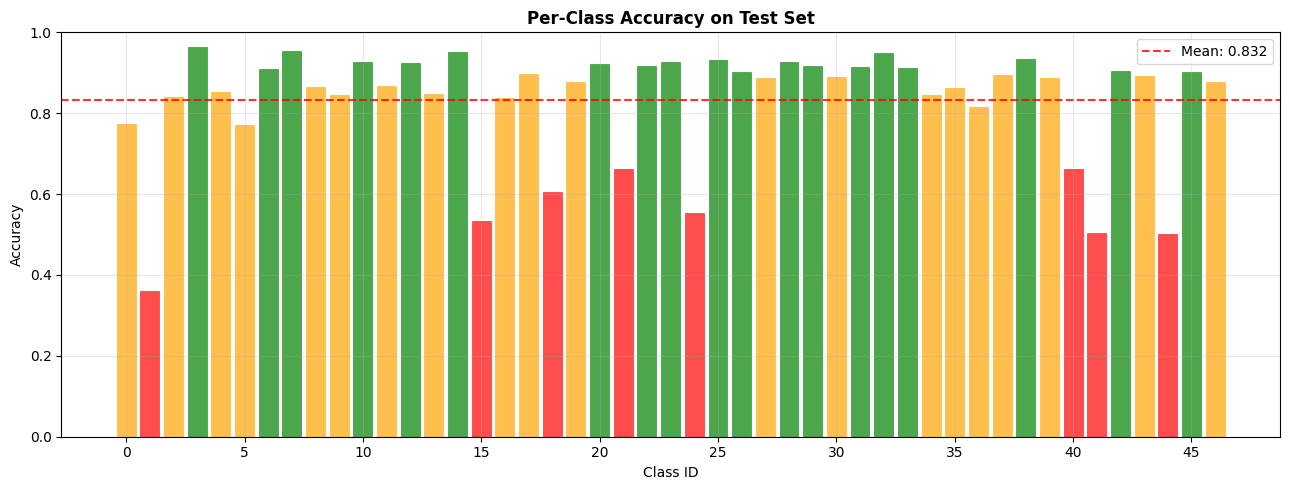

Per-class accuracy statistics:
  Mean: 0.8321
  Std:  0.1405
  Min:  0.3600 (Class 1)
  Max:  0.9625 (Class 3)


In [9]:
# Per-class accuracy analysis
def analyze_per_class_accuracy(true_labels, predictions, num_classes=47):
    """Analyze accuracy for each class"""
    class_accuracies = []
    class_counts = []
    
    for class_id in range(num_classes):
        # Find samples belonging to this class
        class_mask = (true_labels == class_id)
        class_samples = np.sum(class_mask)
        
        if class_samples > 0:
            class_preds = predictions[class_mask]
            class_true = true_labels[class_mask]
            class_acc = np.mean(class_preds == class_true)
        else:
            class_acc = 0
            
        class_accuracies.append(class_acc)
        class_counts.append(class_samples)
    
    return np.array(class_accuracies), np.array(class_counts)

# Analyze per-class accuracy on test set
class_accs, class_counts = analyze_per_class_accuracy(test_true, test_preds)

# Plot per-class accuracy
plt.figure(figsize=(13, 5))
classes = np.arange(47)
bars = plt.bar(classes, class_accs, alpha=0.7, edgecolor='black', linewidth=0.5)

# Color bars based on accuracy
for i, (bar, acc) in enumerate(zip(bars, class_accs)):
    if acc >= 0.9:
        bar.set_color('green')
    elif acc >= 0.7:
        bar.set_color('orange') 
    else:
        bar.set_color('red')

plt.title('Per-Class Accuracy on Test Set', fontsize=12, fontweight='bold')
plt.xlabel('Class ID', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.xticks(classes[::5])  # Show every 5th class label

# Add statistics
mean_acc = np.mean(class_accs)
std_acc = np.std(class_accs)
plt.axhline(y=mean_acc, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_acc:.3f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Per-class accuracy statistics:")
print(f"  Mean: {mean_acc:.4f}")
print(f"  Std:  {std_acc:.4f}")
print(f"  Min:  {np.min(class_accs):.4f} (Class {np.argmin(class_accs)})")
print(f"  Max:  {np.max(class_accs):.4f} (Class {np.argmax(class_accs)})")